This notebook Analyze whether dental coverage increase plan costs.

In [2]:
# Plan Cost and Benefit Structure
# 1- Do plans with enhanced benefit structures cost more in the ACA Marketplace?
# 2- How do average premiums vary across metal levels (Bronze, Silver, Gold)?
# 3- Are dental-only plans priced differently from standard medical plans?
# 4- Does the relationship between plan generosity and cost differ between Tennessee and the national market?
# Analyze whether dental and vision coverage increase plan costs.

In [3]:
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
from datetime import datetime

In [4]:
df_rates = pd.read_csv('../data/Rate_PUF.csv',low_memory=False)

In [5]:
df_rates.head()

,BusinessYear,StateCode,IssuerId,SourceName,ImportDate,RateEffectiveDate,RateExpirationDate,PlanId,RatingAreaId,Tobacco,Age,IndividualRate,IndividualTobaccoRate,Couple,PrimarySubscriberAndOneDependent,PrimarySubscriberAndTwoDependents,PrimarySubscriberAndThreeOrMoreDependents,CoupleAndOneDependent,CoupleAndTwoDependents,CoupleAndThreeOrMoreDependents
0,2026,AK,21989,HIOS,2025-10-15,2026-01-01,2026-12-31,21989AK0030001,Rating Area 1,No Preference,0-14,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,AK,21989,HIOS,2025-10-15,2026-01-01,2026-12-31,21989AK0030001,Rating Area 1,No Preference,15,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,AK,21989,HIOS,2025-10-15,2026-01-01,2026-12-31,21989AK0030001,Rating Area 1,No Preference,16,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,AK,21989,HIOS,2025-10-15,2026-01-01,2026-12-31,21989AK0030001,Rating Area 1,No Preference,17,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,AK,21989,HIOS,2025-10-15,2026-01-01,2026-12-31,21989AK0030001,Rating Area 1,No Preference,18,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_rates_plans = df_rates[['BusinessYear', 'StateCode', 'IssuerId', 'PlanId', 'Age', 'IndividualRate']]
df_rates_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2235761 entries, 0 to 2235760
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   BusinessYear    int64  
 1   StateCode       object 
 2   IssuerId        int64  
 3   PlanId          object 
 4   Age             object 
 5   IndividualRate  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 102.3+ MB


In [7]:
df_rates_plans.columns = (df_rates_plans.columns.str.lower().str.strip().str.replace(" ", "_"))
df_rates_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2235761 entries, 0 to 2235760
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   businessyear    int64  
 1   statecode       object 
 2   issuerid        int64  
 3   planid          object 
 4   age             object 
 5   individualrate  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 102.3+ MB


In [8]:
df_rates_plans = df_rates_plans[df_rates_plans['businessyear'] == 2026] 
df_rates_plans

,businessyear,statecode,issuerid,planid,age,individualrate
0,2026,AK,21989,21989AK0030001,0-14,65.00
1,2026,AK,21989,21989AK0030001,15,65.00
2,2026,AK,21989,21989AK0030001,16,65.00
3,2026,AK,21989,21989AK0030001,17,65.00
4,2026,AK,21989,21989AK0030001,18,65.00
...,...,...,...,...,...,...
2235756,2026,WY,83964,83964WY0040002,60,44.57
2235757,2026,WY,83964,83964WY0040002,61,44.57
2235758,2026,WY,83964,83964WY0040002,62,44.57
2235759,2026,WY,83964,83964WY0040002,63,44.57


In [9]:
 #df_rates_plans = df_rates_plans[df_rates_plans['age'] == '40']
 #df_rates_plans

In [10]:
df_attributes = pd.read_csv('../data/plan_attributes_PUF.csv',low_memory=False)

In [11]:
df_attributes.head()

,BusinessYear,StateCode,IssuerId,IssuerMarketPlaceMarketingName,SourceName,ImportDate,MarketCoverage,DentalOnlyPlan,StandardComponentId,PlanMarketingName,...,TEHBDedOutOfNetFamilyPerPerson,TEHBDedOutOfNetFamilyPerGroup,TEHBDedCombInnOonIndividual,TEHBDedCombInnOonFamilyPerPerson,TEHBDedCombInnOonFamilyPerGroup,IsHSAEligible,HSAOrHRAEmployerContribution,HSAOrHRAEmployerContributionAmount,URLForSummaryofBenefitsCoverage,PlanBrochure
0,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
1,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
2,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
3,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
4,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0050002,Delta Dental PPO 1500 Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...


In [12]:
df_attributes.columns

Index(['BusinessYear', 'StateCode', 'IssuerId',
       'IssuerMarketPlaceMarketingName', 'SourceName', 'ImportDate',
       'MarketCoverage', 'DentalOnlyPlan', 'StandardComponentId',
       'PlanMarketingName',
       ...
       'TEHBDedOutOfNetFamilyPerPerson', 'TEHBDedOutOfNetFamilyPerGroup',
       'TEHBDedCombInnOonIndividual', 'TEHBDedCombInnOonFamilyPerPerson',
       'TEHBDedCombInnOonFamilyPerGroup', 'IsHSAEligible',
       'HSAOrHRAEmployerContribution', 'HSAOrHRAEmployerContributionAmount',
       'URLForSummaryofBenefitsCoverage', 'PlanBrochure'],
      dtype='object', length=151)

In [13]:
df_attr_plans = df_attributes[['BusinessYear', 'StateCode', 'IssuerId', 'IssuerMarketPlaceMarketingName', 'MarketCoverage', 'DentalOnlyPlan',
                     'StandardComponentId', 'PlanMarketingName', 'MetalLevel', 'IsHSAEligible']]
df_attr_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22059 entries, 0 to 22058
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   BusinessYear                    22059 non-null  int64 
 1   StateCode                       22059 non-null  object
 2   IssuerId                        22059 non-null  int64 
 3   IssuerMarketPlaceMarketingName  22059 non-null  object
 4   MarketCoverage                  22059 non-null  object
 5   DentalOnlyPlan                  22059 non-null  object
 6   StandardComponentId             22059 non-null  object
 7   PlanMarketingName               22059 non-null  object
 8   MetalLevel                      22059 non-null  object
 9   IsHSAEligible                   20670 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.7+ MB


In [14]:
df_attr_plans.columns = (df_attr_plans.columns.str.lower().str.strip().str.replace(" ", "_"))
df_attr_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22059 entries, 0 to 22058
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   businessyear                    22059 non-null  int64 
 1   statecode                       22059 non-null  object
 2   issuerid                        22059 non-null  int64 
 3   issuermarketplacemarketingname  22059 non-null  object
 4   marketcoverage                  22059 non-null  object
 5   dentalonlyplan                  22059 non-null  object
 6   standardcomponentid             22059 non-null  object
 7   planmarketingname               22059 non-null  object
 8   metallevel                      22059 non-null  object
 9   ishsaeligible                   20670 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.7+ MB


In [15]:
df_attr_plans = df_attr_plans[(df_attr_plans['businessyear'] == 2026) & 
                (df_attr_plans['marketcoverage'] == 'Individual')]
df_attr_plans.head()

,businessyear,statecode,issuerid,issuermarketplacemarketingname,marketcoverage,dentalonlyplan,standardcomponentid,planmarketingname,metallevel,ishsaeligible
0,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
1,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
2,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
3,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
4,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050002,Delta Dental PPO 1500 Plan,High,NaN


In [16]:
df_q2 = df_rates_plans.merge(df_attr_plans, left_on='planid', right_on='standardcomponentid', how='inner')
df_q2.shape

(7173772, 16)

In [17]:
df_q2.columns

Index(['businessyear_x', 'statecode_x', 'issuerid_x', 'planid', 'age',
       'individualrate', 'businessyear_y', 'statecode_y', 'issuerid_y',
       'issuermarketplacemarketingname', 'marketcoverage', 'dentalonlyplan',
       'standardcomponentid', 'planmarketingname', 'metallevel',
       'ishsaeligible'],
      dtype='object')

In [18]:
df_q2 = df_q2.rename(columns={'statecode_x': 'statecode','issuerid_x': 'issuerid','businessyear_x': 'businessyear'}).drop(columns=['statecode_y',
    'issuerid_y', 'businessyear_y', 'standardcomponentid'])

In [19]:
df_q2.groupby('statecode')['dentalonlyplan'].apply(lambda x: (x == 'Yes').sum()).mean()

31547.233333333334

In [20]:
df_q2.groupby('statecode')['dentalonlyplan'].apply(lambda x: (x == 'No').sum()).mean()

207578.5

In [21]:
dental_cost = (df_q2.groupby('dentalonlyplan')['individualrate'].mean().reset_index())
dental_cost

,dentalonlyplan,individualrate
0,No,890.221653
1,Yes,57.463368


In [22]:
df_q2[df_q2["statecode"] == "TN"].groupby('dentalonlyplan')['individualrate'].mean().reset_index()

,dentalonlyplan,individualrate
0,No,865.090789
1,Yes,18.877867


In [23]:
df_q2[df_q2["statecode"] == "TN"]["dentalonlyplan"].value_counts()

dentalonlyplan
No     115923
Yes     17748
Name: count, dtype: int64

In [24]:
df_medical = df_q2[df_q2['dentalonlyplan'] == "No"]
df_medical

,businessyear,statecode,issuerid,planid,age,individualrate,issuermarketplacemarketingname,marketcoverage,dentalonlyplan,planmarketingname,metallevel,ishsaeligible
867,2026,AK,38344,38344AK1060001,0-14,568.96,Premera Blue Cross Blue Shield of Alaska,Individual,No,Premera Blue Cross Preferred Gold 1500,Gold,No
868,2026,AK,38344,38344AK1060001,0-14,568.96,Premera Blue Cross Blue Shield of Alaska,Individual,No,Premera Blue Cross Preferred Gold 1500,Gold,No
869,2026,AK,38344,38344AK1060001,0-14,568.96,Premera Blue Cross Blue Shield of Alaska,Individual,No,Premera Blue Cross Preferred Gold 1500,Gold,No
870,2026,AK,38344,38344AK1060001,15,619.54,Premera Blue Cross Blue Shield of Alaska,Individual,No,Premera Blue Cross Preferred Gold 1500,Gold,No
871,2026,AK,38344,38344AK1060001,15,619.54,Premera Blue Cross Blue Shield of Alaska,Individual,No,Premera Blue Cross Preferred Gold 1500,Gold,No
...,...,...,...,...,...,...,...,...,...,...,...,...
7172237,2026,WY,49714,49714WY0210003,63,2576.10,UnitedHealthcare,Individual,No,"UHC Gold Advantage+ ($0 Virtual Urgent Care, $...",Gold,No
7172238,2026,WY,49714,49714WY0210003,64 and over,2617.98,UnitedHealthcare,Individual,No,"UHC Gold Advantage+ ($0 Virtual Urgent Care, $...",Gold,No
7172239,2026,WY,49714,49714WY0210003,64 and over,2617.98,UnitedHealthcare,Individual,No,"UHC Gold Advantage+ ($0 Virtual Urgent Care, $...",Gold,No
7172240,2026,WY,49714,49714WY0210003,64 and over,2617.98,UnitedHealthcare,Individual,No,"UHC Gold Advantage+ ($0 Virtual Urgent Care, $...",Gold,No


# analyze cost by metal level

In [26]:
metal_cost = (df_medical.groupby('metallevel')['individualrate'].mean().sort_values().reset_index())
metal_cost

,metallevel,individualrate
0,Catastrophic,540.101080
1,Bronze,694.564920
2,Expanded Bronze,702.103827
3,Silver,910.176637
4,Gold,966.082144
5,Platinum,1877.259340


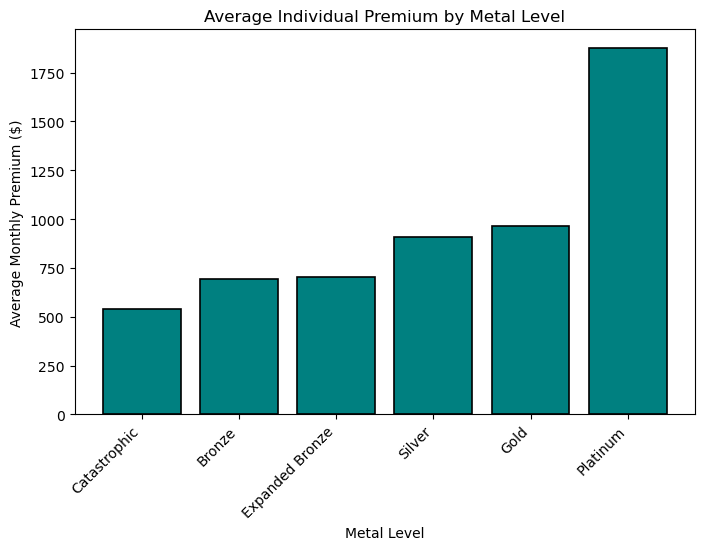

In [27]:
plt.figure(figsize=(8,5))
plt.bar(metal_cost['metallevel'],metal_cost['individualrate'],
        color=['teal'], edgecolor='black', linewidth=1.2)
plt.title('Average Individual Premium by Metal Level')
plt.xlabel('Metal Level')
plt.ylabel('Average Monthly Premium ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [28]:
df_tn = df_medical[df_medical['statecode'] == "TN"]

In [29]:
metal_cost_tn = (df_tn.groupby('metallevel')['individualrate'].mean().reset_index())
metal_cost_tn

,metallevel,individualrate
0,Bronze,660.378686
1,Expanded Bronze,718.442108
2,Gold,950.202019
3,Platinum,1032.458039
4,Silver,924.779324


In [30]:
df_us = df_medical

In [31]:
metal_cost_us = (df_us.groupby('metallevel')['individualrate'].mean().reset_index())
metal_cost_us

,metallevel,individualrate
0,Bronze,694.564920
1,Catastrophic,540.101080
2,Expanded Bronze,702.103827
3,Gold,966.082144
4,Platinum,1877.259340
5,Silver,910.176637


In [32]:
df_compare = metal_cost_us.merge(metal_cost_tn, on='metallevel', suffixes=("_us", "_tn"))
df_compare

,metallevel,individualrate_us,individualrate_tn
0,Bronze,694.564920,660.378686
1,Expanded Bronze,702.103827,718.442108
2,Gold,966.082144,950.202019
3,Platinum,1877.259340,1032.458039
4,Silver,910.176637,924.779324


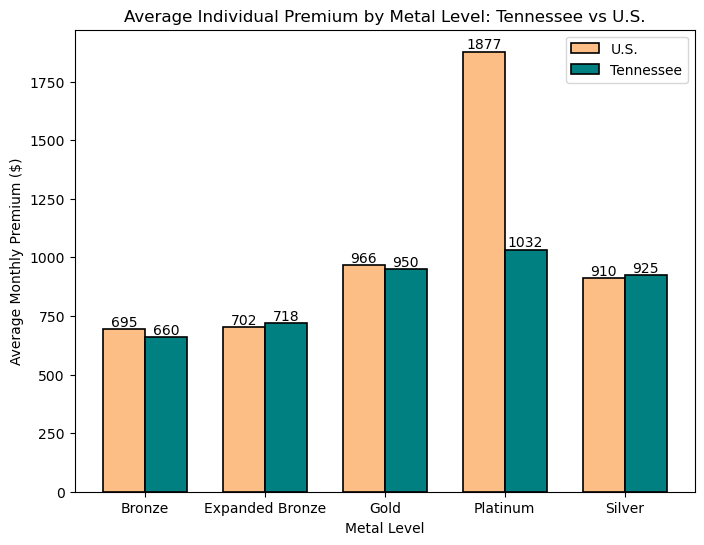

In [77]:
x = np.arange(len(df_compare['metallevel']))
width = 0.35

plt.figure(figsize=(8,6))
bars1 = plt.bar(x - width/2, df_compare['individualrate_us'], width, label="U.S.", color='#fdbe85', edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x + width/2, df_compare['individualrate_tn'], width, label="Tennessee", color='teal', edgecolor='black', linewidth=1.2)

plt.xticks(x, df_compare['metallevel'])
plt.ylabel('Average Monthly Premium ($)')
plt.xlabel('Metal Level')
plt.title('Average Individual Premium by Metal Level: Tennessee vs U.S.')

plt.legend()
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.0f}", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.0f}", ha='center', va='bottom')
plt.show()

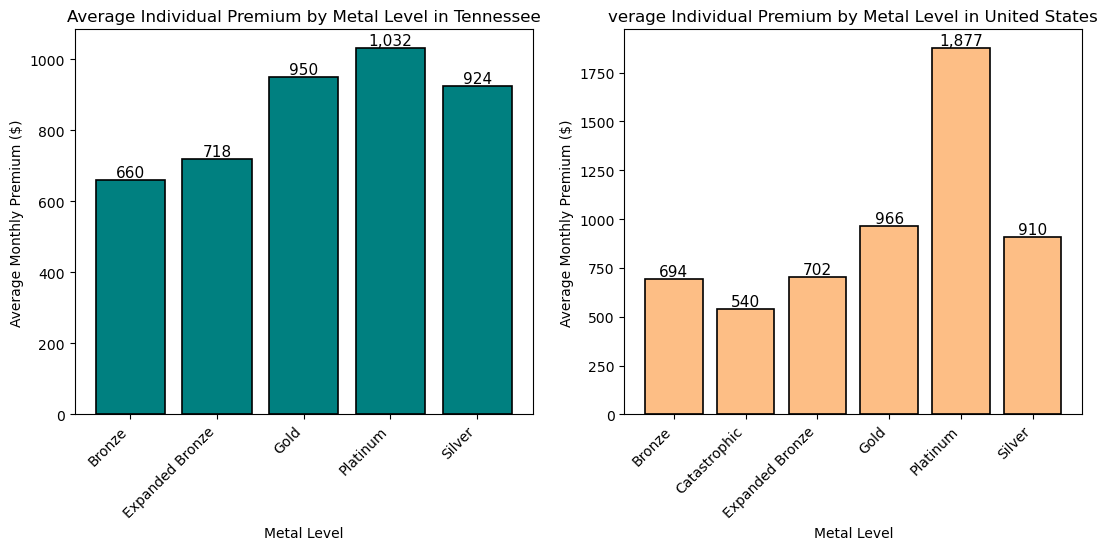

In [35]:
plt.figure(figsize=(13,5))
plt.subplot(1, 2, 1) 
bars = plt.bar(metal_cost_tn['metallevel'], metal_cost_tn['individualrate'], color=['teal'], edgecolor='black',linewidth=1.2)
plt.title('Average Individual Premium by Metal Level in Tennessee')
plt.ylabel('Average Monthly Premium ($)')
plt.xlabel('Metal Level')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.subplot(1, 2, 2) 
bars = plt.bar(metal_cost_us['metallevel'], metal_cost_us['individualrate'], color=['#fdbe85'], edgecolor='black',linewidth=1.2)
plt.title('verage Individual Premium by Metal Level in United States')
plt.ylabel('Average Monthly Premium ($)')
plt.xlabel('Metal Level')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.show()